Phase 2
-----------
Engineer & Transform Features
--------------------------------
goals: explore relationships between features and prepare data for modeling

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df=pd.read_csv("AmesHousing.csv")
print(df.head())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [ ]:
# The connection here is to create an alley name on the street.
df_ohe=pd.get_dummies(df,columns=["Street"],prefix=["Alley"])
print(df_ohe.head())
# the code create new colunm like Alley_Grvl,Alley_Pave

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Alley  \
0      1  526301100           20        RL         141.0     31770   NaN   
1      2  526350040           20        RH          80.0     11622   NaN   
2      3  526351010           20        RL          81.0     14267   NaN   
3      4  526353030           20        RL          93.0     11160   NaN   
4      5  527105010           60        RL          74.0     13830   NaN   

  Lot Shape Land Contour Utilities  ...  Fence Misc Feature Misc Val Mo Sold  \
0       IR1          Lvl    AllPub  ...    NaN          NaN        0       5   
1       Reg          Lvl    AllPub  ...  MnPrv          NaN        0       6   
2       IR1          Lvl    AllPub  ...    NaN         Gar2    12500       6   
3       Reg          Lvl    AllPub  ...    NaN          NaN        0       4   
4       IR1          Lvl    AllPub  ...  MnPrv          NaN        0       3   

  Yr Sold Sale Type Sale Condition  SalePrice  Alley_Grvl  All

In [5]:
Ms_subClass=pd.CategoricalIndex(df["MS SubClass"],ordered=True)
print(Ms_subClass.categories)

Index([20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190], dtype='int64')


In [6]:
from sklearn.preprocessing import StandardScaler
# here I used StandardScaler()
std_scaler=StandardScaler()
# here I copied the (df)
df_std=df.copy()
df_std[["Lot Frontage_std","Lot Area_std"]]=std_scaler.fit_transform(df_std[["Lot Frontage","Lot Area"]])
print(df_std[["Lot Frontage","Lot Area","Lot Frontage_std","Lot Area_std"]])


      Lot Frontage  Lot Area  Lot Frontage_std  Lot Area_std
0            141.0     31770          3.072506      2.744381
1             80.0     11622          0.461265      0.187097
2             81.0     14267          0.504073      0.522814
3             93.0     11160          1.017759      0.128458
4             74.0     13830          0.204422      0.467348
...            ...       ...               ...           ...
2925          37.0      7937         -1.379445     -0.280621
2926           NaN      8885               NaN     -0.160296
2927          62.0     10441         -0.309265      0.037199
2928          77.0     10010          0.332844     -0.017506
2929          74.0      9627          0.204422     -0.066118

[2930 rows x 4 columns]


In [7]:
# i used ai and i learnd how to use (where)
df["price_per_sqft"]=np.where(df["Gr Liv Area"]>0,df["Gr Liv Area"]/df["SalePrice"],0)

df["room_per_sqft"]=np.where(df["Gr Liv Area"]>0,df["TotRms AbvGrd"]/df["Gr Liv Area"],0)

print(df["price_per_sqft"])
print(df["room_per_sqft"])

0       0.007702
1       0.008533
2       0.007727
3       0.008648
4       0.008578
          ...   
2925    0.007039
2926    0.006885
2927    0.007348
2928    0.008171
2929    0.010638
Name: price_per_sqft, Length: 2930, dtype: float64
0       0.004227
1       0.005580
2       0.004515
3       0.003791
4       0.003683
          ...   
2925    0.005982
2926    0.005543
2927    0.006186
2928    0.004320
2929    0.004500
Name: room_per_sqft, Length: 2930, dtype: float64


In [ ]:
# Here, the relationship between the general condition and the area of ​​a plot of land gives the overall rating.
df["Overall ratting"]=df["Lot Area"]*df["Overall Qual"]
print(df["Overall ratting"])

0       190620
1        58110
2        85602
3        78120
4        69150
         ...  
2925     47622
2926     44425
2927     52205
2928     50050
2929     67389
Name: Overall ratting, Length: 2930, dtype: int64


0       4.955827
1       4.394449
2       4.406719
3       4.543295
4       4.317488
          ...   
2925    3.637586
2926         NaN
2927    4.143135
2928    4.356709
2929    4.317488
Name: Lot Frontage_log, Length: 2930, dtype: float64


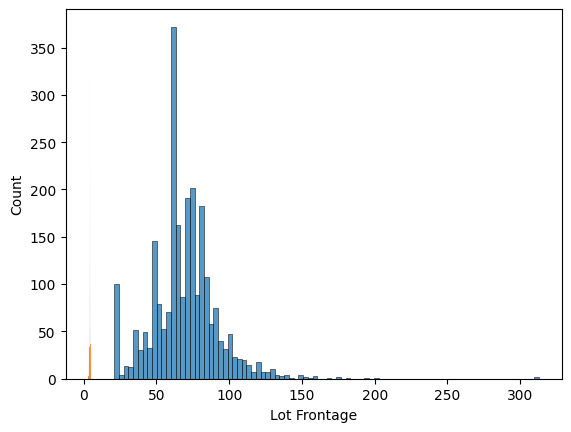

In [9]:
df["Lot Frontage_log"]= np.log1p(df["Lot Frontage"])
# it is print the old one
sns.histplot(df["Lot Frontage"])
# it is print the new one after log1p
sns.histplot(df["Lot Frontage_log"])
print(df["Lot Frontage_log"])

In [10]:
# i used ai to debug how can i but the final values into the (df["rate"]) and i but (=) from ai
rates=[]
# Here I used the (for) function to input all the data and divide it
for i in df["Year Built"]:
      if i >= 1988 and i <= 1999:
        rates.append("NEW")
      elif i >= 2001:
        rates.append("RECENT")
      else:
        rates.append("OLD")
# Here I used it to record it in the data frame
df["rate"]=rates

In [11]:
print(df["rate"])

0       OLD
1       OLD
2       OLD
3       OLD
4       NEW
       ... 
2925    OLD
2926    OLD
2927    NEW
2928    OLD
2929    NEW
Name: rate, Length: 2930, dtype: object


In [12]:
# i used ai
corr_matrix=df.select_dtypes(include="number").corr().abs()
todrop=set()
for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if corr_matrix.iloc[i,j]>0.95:
      clname=corr_matrix.columns[i]
      todrop.add(clname)
df_sim=df.drop(columns=todrop)
print(f"what need to drop ={todrop}")


what need to drop ={'Yr Sold'}
